# PART C: Demand correlation analysis

### Time spent: 30 mins
*Early Hypothesis: Site demand increases in the days following movie releases, especially days after multiple movie releases*

#### Done so far..
- identified how many filmed are released on each date
- plotted simple graphs to compare average sales surrounding dates with different number of films released
- looked into netsales on release days, sum of netsales 3 days before, and sum of netsales 3 days after
- Insights so far: it appears that sales go up after movie releases and NOT before, suggesting that people buy tickets once films are released as opposed to buying them in advance of the release date
- Hypothesis made looking at intial (graphs displayed below)

#### With more time to take this analysis futher..
- develop further the idea of looking at multiple days of sales surrounding release dates to see if there is a number of days that provides a clearer relationship than looking at 3 days
- seperate films by languages and genres and see if there are different relationships between sales and release dates for these categories
- use additional features generated from part A and analyse possible relationships with site demand
- analysis so far doesnt consider factors such as the impact of multiple days without any movie releases

In [153]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as çplt
from datetime import datetime, timedelta
df = pd.read_csv('releases.csv')
dd = pd.read_csv('demand_data.csv')

In [156]:
# filter for 2023 (used period)
mask = [i[:4] == "2023" for i in dd.sort_values('date').date]
dd_2023 = dd.sort_values('date')[mask].reset_index(drop=True)

# value counts of release dates
release_date_count = df.release_date.value_counts().to_frame().reset_index().rename(columns={"release_date":"date"})

# merging with original demand data
dd_2023 = dd_2023.merge(release_date_count, on="date", how="left").fillna(0)

# to datetime
dd_2023.date = [datetime.strptime(i, "%Y-%m-%d") for i in dd_2023.date]

# sum of sales 3 days prior
sum_of_sales_past_3_days = [dd_2023.netsales.values[i:i+3].sum() for i in range(len(dd_2023)-3)]
dd_2023['sum_of_sales_past_3_days'] = [np.nan] * 3 + sum_of_sales_past_3_days

# sum of sales 3 days after
sum_of_sales_next_3_days = [dd_2023.netsales.values[i:i+3].sum() for i in range(1,len(dd_2023)-2)]
dd_2023['sum_of_sales_next_3_days'] = sum_of_sales_next_3_days + [np.nan] * 3

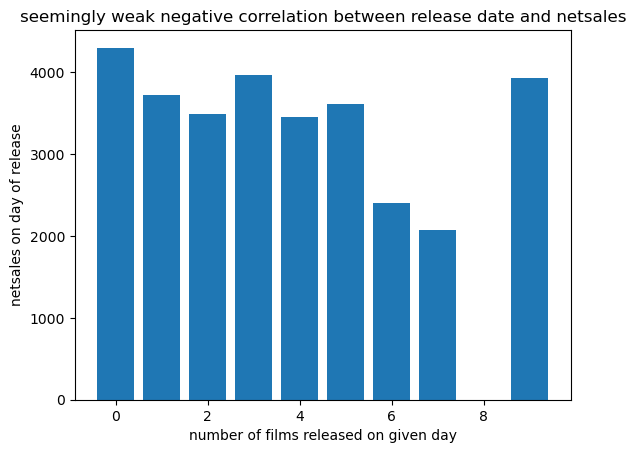

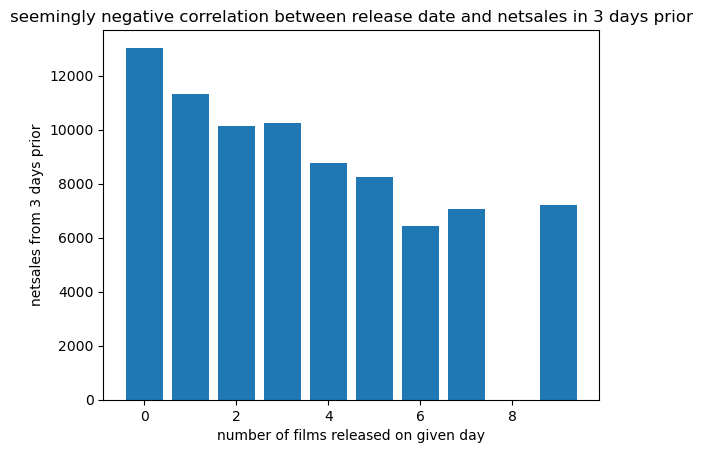

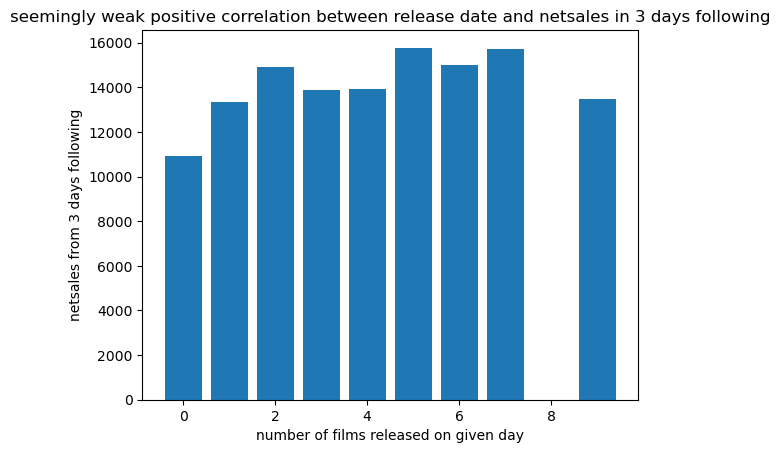

In [157]:
plt.plot()
plt.bar(dd_2023.groupby("count")["netsales"].mean().index, dd_2023.groupby("count")["netsales"].mean().values)
plt.xlabel('number of films released on given day')
plt.ylabel('netsales on day of release')
plt.title('seemingly weak negative correlation between release date and netsales')
plt.show()

plt.plot()
plt.bar(dd_2023.groupby("count")["sum_of_sales_past_3_days"].mean().index, dd_2023.groupby("count")["sum_of_sales_past_3_days"].mean().values)
plt.xlabel('number of films released on given day')
plt.ylabel('netsales from 3 days prior')
plt.title('seemingly negative correlation between release date and netsales in 3 days prior')
plt.show()

plt.plot()
plt.bar(dd_2023.groupby("count")["sum_of_sales_next_3_days"].mean().index, dd_2023.groupby("count")["sum_of_sales_next_3_days"].mean().values)
plt.xlabel('number of films released on given day')
plt.ylabel('netsales from 3 days following')
plt.title('seemingly weak positive correlation between release date and netsales in 3 days following')
plt.show()